# Market Basket Analysis — Retail Purchase Affinity

**Author:** Aman Bohra · Senior Analytics & BI Professional
**Portfolio:** https://amandbohra.github.io/portfolio/

This notebook demonstrates the analytical approach behind my supply-chain work, where I applied the
**Apriori algorithm** to Bill-of-Materials hierarchies to reduce inventory costs by ~15% and improve
supply-chain accuracy by ~20%.

Here I use the same technique on a **synthetic retail dataset** — market basket analysis to uncover which
products are frequently bought together, and turn those patterns into **association rules** for
cross-sell, bundling, and planogram decisions.

> ⚠️ **Note:** All data below is randomly generated for demonstration. No real or confidential client
> data is used.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.25})
rng = np.random.default_rng(42)


## 1. Generate synthetic transactions

We simulate 2,000 baskets from a small catalogue, deliberately planting a few real-world affinities
(e.g. *bread + butter + milk*, *pasta + pasta sauce*, *diapers + baby wipes*) so the algorithm has
genuine patterns to recover.

In [2]:
catalogue = ["Bread","Butter","Milk","Eggs","Coffee","Pasta","Pasta Sauce",
             "Diapers","Baby Wipes","Beer","Chips","Cheese","Tomatoes","Cereal"]

# affinity groups that often co-occur
affinities = [
    (["Bread","Butter","Milk"], 0.55),
    (["Pasta","Pasta Sauce","Tomatoes"], 0.50),
    (["Diapers","Baby Wipes"], 0.60),
    (["Beer","Chips"], 0.45),
    (["Coffee","Milk"], 0.40),
    (["Bread","Cheese"], 0.35),
]

def make_basket():
    items = set()
    # seed with 0-2 affinity groups
    for group, p in affinities:
        if rng.random() < p * 0.6:
            for it in group:
                if rng.random() < p:
                    items.add(it)
    # add random noise items
    for it in rng.choice(catalogue, size=rng.integers(0, 3), replace=False):
        items.add(it)
    if not items:
        items.add(rng.choice(catalogue))
    return sorted(items)

transactions = [make_basket() for _ in range(2000)]
print(f"{len(transactions)} baskets generated")
print("Example baskets:")
for t in transactions[:5]:
    print("  ", t)


2000 baskets generated
Example baskets:
   [np.str_('Butter')]
   [np.str_('Eggs')]
   [np.str_('Cereal'), 'Milk']
   ['Bread', 'Butter', np.str_('Chips'), 'Milk', 'Pasta', 'Pasta Sauce']
   [np.str_('Diapers'), 'Pasta Sauce', 'Tomatoes']


## 2. One-hot encode the baskets

Apriori needs a one-hot (boolean) matrix: one row per basket, one column per product.

In [3]:
te = TransactionEncoder()
onehot = te.fit(transactions).transform(transactions)
basket_df = pd.DataFrame(onehot, columns=te.columns_)
basket_df.head()


,Baby Wipes,Beer,Bread,Butter,Cereal,Cheese,Chips,Coffee,Diapers,Eggs,Milk,Pasta,Pasta Sauce,Tomatoes
0,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,False,False,False,False
2,False,False,False,False,True,False,False,False,False,False,True,False,False,False
3,False,False,True,True,False,False,True,False,False,False,True,True,True,False
4,False,False,False,False,False,False,False,False,True,False,False,False,True,True


## 3. Frequent itemsets (Apriori)

`min_support = 0.04` keeps itemsets that appear in at least ~4% of baskets.

In [4]:
freq = apriori(basket_df, min_support=0.04, use_colnames=True)
freq["itemsets"] = freq["itemsets"].apply(lambda s: ", ".join(sorted(s)))
freq = freq.sort_values("support", ascending=False).reset_index(drop=True)
freq.head(12)


,support,itemsets
0,0.3100,Milk
1,0.3005,Bread
2,0.2860,Diapers
3,0.2820,Baby Wipes
4,0.2375,Butter
5,0.2120,Pasta Sauce
6,0.2045,Pasta
7,0.2035,Tomatoes
8,0.1910,Chips
9,0.1875,Beer


## 4. Association rules

We generate rules and rank by **lift** (how much more likely the consequent is, given the antecedent,
versus baseline). Lift > 1 = positive association.

In [5]:
freq2 = apriori(basket_df, min_support=0.04, use_colnames=True)
rules = association_rules(freq2, metric="lift", min_threshold=1.1)

def fmt(s):
    return ", ".join(sorted(s))
rules["antecedents"] = rules["antecedents"].apply(fmt)
rules["consequents"] = rules["consequents"].apply(fmt)
top = (rules[["antecedents","consequents","support","confidence","lift"]]
       .sort_values("lift", ascending=False)
       .round(3)
       .head(12)
       .reset_index(drop=True))
top


,antecedents,consequents,support,confidence,lift
0,Diapers,"Baby Wipes, Milk",0.056,0.194,2.156
1,"Baby Wipes, Milk",Diapers,0.056,0.617,2.156
2,Butter,"Bread, Milk",0.069,0.291,2.098
3,"Bread, Milk",Butter,0.069,0.498,2.098
4,Baby Wipes,"Diapers, Milk",0.056,0.197,2.094
5,"Diapers, Milk",Baby Wipes,0.056,0.590,2.094
6,Baby Wipes,"Bread, Diapers",0.048,0.170,2.051
7,"Bread, Diapers",Baby Wipes,0.048,0.578,2.051
8,Milk,"Bread, Butter",0.069,0.223,1.935
9,"Bread, Butter",Milk,0.069,0.600,1.935


## 5. Visualise the strongest rules

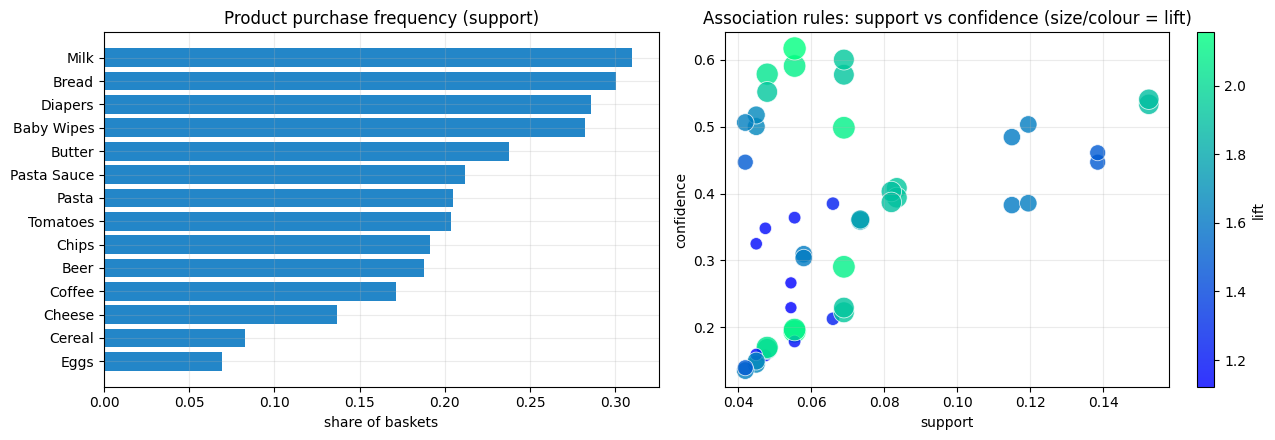

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) item frequency
freqs = basket_df.mean().sort_values(ascending=True)
axes[0].barh(freqs.index, freqs.values, color="#2386c8")
axes[0].set_title("Product purchase frequency (support)")
axes[0].set_xlabel("share of baskets")

# (b) support vs confidence, sized by lift
sc = axes[1].scatter(rules["support"], rules["confidence"],
                     s=(rules["lift"]**2)*60, c=rules["lift"],
                     cmap="winter", alpha=0.8, edgecolors="white", linewidths=0.6)
axes[1].set_title("Association rules: support vs confidence (size/colour = lift)")
axes[1].set_xlabel("support"); axes[1].set_ylabel("confidence")
fig.colorbar(sc, ax=axes[1], label="lift")
plt.tight_layout()
plt.show()


## 6. From patterns to business value

The rules above translate directly into decisions:

- **Cross-sell / bundling** — pair high-lift items (e.g. *Pasta → Pasta Sauce*) in promotions and
  recommendation widgets.
- **Planogram & placement** — co-locate frequently-linked products to lift basket size.
- **Inventory & replenishment** — forecast linked items together to avoid stock-outs on the "partner"
  product; this is exactly the lever I used on Bill-of-Materials data to cut inventory cost ~15%.
- **Targeted marketing** — build segments around association rules rather than single-product behaviour.

**The point:** the algorithm is a means, not the end. The value is in translating *"these items move
together"* into a decision someone in the business actually makes.

---
*Reproduce:* `pip install pandas mlxtend matplotlib` then run this notebook top to bottom.
